# Academic Stress and Student Well-being

This project looks at whether study load, sleep quality, and social support are related to students' stress levels.

The data are observational, so the results are interpreted as associations, not causes.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Save the final figures in one place
project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
figure_dir = project_root / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)


## Data

The dataset used in this project is `StressLevelDataset.csv`.

Source: Student Stress Factors dataset on Kaggle  
https://www.kaggle.com/datasets/samyakb/student-stress-factors

The file contains 1,100 observations and 21 variables. For the analysis, the main variables are:

- `stress_level`
- `study_load`
- `sleep_quality`
- `social_support`

I first checked the size of the data, missing values, duplicate rows, and the range of the variables before starting the analysis.


## Read the data


In [2]:
# Find the dataset
from pathlib import Path

DATA_PATH = Path("data/StressLevelDataset.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("../data/StressLevelDataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


## Make a copy of the data


In [3]:
df_raw = df.copy()
df_clean = df.copy()

print("Dataset copies created successfully.")


Dataset copies created successfully.


## Basic data checks

Before doing any statistical analysis, I checked the data types, missing values, duplicates, and the observed range of each variable.


In [4]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
})

numeric_cols = df.select_dtypes(include=np.number).columns
audit.loc[numeric_cols, "min"] = df[numeric_cols].min()
audit.loc[numeric_cols, "max"] = df[numeric_cols].max()

print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

display(audit)


Shape: (1100, 21)
Missing values: 0
Duplicate rows: 0


,dtype,missing_n,missing_pct,n_unique,min,max
anxiety_level,int64,0,0.0,22,0.0,21.0
self_esteem,int64,0,0.0,31,0.0,30.0
mental_health_history,int64,0,0.0,2,0.0,1.0
depression,int64,0,0.0,28,0.0,27.0
headache,int64,0,0.0,6,0.0,5.0
blood_pressure,int64,0,0.0,3,1.0,3.0
sleep_quality,int64,0,0.0,6,0.0,5.0
breathing_problem,int64,0,0.0,6,0.0,5.0
noise_level,int64,0,0.0,6,0.0,5.0
living_conditions,int64,0,0.0,6,0.0,5.0


In [5]:
missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())

print("Data-quality summary")
print("-" * 40)

if missing_total == 0:
    print("No missing values were found.")
else:
    print(f"{missing_total} missing values were found and should be handled before modeling.")

if duplicate_total == 0:
    print("No exact duplicate rows were found.")
else:
    print(f"{duplicate_total} exact duplicate rows were found and should be checked before removal.")

print("\nObserved ranges for the variables used in this study:")
for col in ["stress_level", "study_load", "sleep_quality", "social_support"]:
    print(f"{col}: {df[col].min()} to {df[col].max()}")

unexpected_stress = sorted(set(df["stress_level"].dropna().unique()) - {0, 1, 2})
if unexpected_stress:
    print(f"Unexpected stress_level codes: {unexpected_stress}")
else:
    print("\nstress_level only contains the expected codes 0, 1, and 2.")


Data-quality summary
----------------------------------------
No missing values were found.
No exact duplicate rows were found.

Observed ranges for the variables used in this study:
stress_level: 0 to 2
study_load: 0 to 5
sleep_quality: 0 to 5
social_support: 0 to 3

stress_level only contains the expected codes 0, 1, and 2.


### Data-cleaning decision

The dataset has 1,100 rows and 21 variables. No missing values or exact duplicate rows were found,
so no rows were removed for these reasons.

For the variables used in this study, the observed ranges were:

- `stress_level`: 0 to 2
- `study_load`: 0 to 5
- `sleep_quality`: 0 to 5
- `social_support`: 0 to 3

`stress_level` contained only the expected codes 0, 1, and 2. Based on these checks, I kept the
original observations and did not apply imputation or duplicate removal.


In [6]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "stress_level",
        "study_load",
        "sleep_quality",
        "social_support"
    ],
    "Role": [
        "Outcome",
        "Predictor",
        "Predictor",
        "Predictor"
    ],
    "Type": [
        "Ordinal categorical",
        "Ordinal score",
        "Ordinal score",
        "Ordinal score"
    ],
    "Coding / observed range": [
        "0 = Low, 1 = Medium, 2 = High",
        "0 to 5",
        "0 to 5",
        "0 to 3"
    ]
})

data_dictionary


,Variable,Role,Type,Coding / observed range
0,stress_level,Outcome,Ordinal categorical,"0 = Low, 1 = Medium, 2 = High"
1,study_load,Predictor,Ordinal score,0 to 5
2,sleep_quality,Predictor,Ordinal score,0 to 5
3,social_support,Predictor,Ordinal score,0 to 3


The dataset file does not include the full questionnaire wording or all scale anchors for the
predictor scores. I therefore treat these variables as ordered scores and interpret one-unit
differences cautiously rather than assuming that the distance between every pair of adjacent
scores has an exact psychological meaning.


In [7]:
main_variables = [
    "stress_level",
    "study_load",
    "sleep_quality",
    "social_support"
]

for col in main_variables:
    print(f"\nVariable: {col}")
    print("dtype:", df[col].dtype)
    print("Unique values:", sorted(df[col].unique()))
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().sort_index())



Variable: stress_level
dtype: int64
Unique values: [np.int64(0), np.int64(1), np.int64(2)]
Number of unique values: 3
stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Variable: study_load
dtype: int64
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Number of unique values: 6
study_load
0     37
1    185
2    333
3    275
4    142
5    128
Name: count, dtype: int64

Variable: sleep_quality
dtype: int64
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Number of unique values: 6
sleep_quality
0     34
1    328
2    188
3    170
4    188
5    192
Name: count, dtype: int64

Variable: social_support
dtype: int64
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Number of unique values: 4
social_support
0     88
1    412
2    142
3    458
Name: count, dtype: int64


## Variables used in the analysis

The outcome is `stress_level`, with three ordered categories:

- 0 = low stress
- 1 = medium stress
- 2 = high stress

The main explanatory variables are `study_load`, `sleep_quality`, and `social_support`.

These variables are recorded as ordered scores. In the regression models, I treat them as numeric scores. This means that a one-unit increase is assumed to have the same type of effect across the scale, so this assumption should be kept in mind when interpreting the results.


In [8]:
for col in ["stress_level", "study_load", "sleep_quality", "social_support"]:
    print(f"\n--- {col} ---")
    
    table = pd.DataFrame({
        "Count": df[col].value_counts().sort_index(),
        "Percent": (
            df[col].value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    })
    
    print(table)



--- stress_level ---
              Count  Percent
stress_level                
0               373    33.91
1               358    32.55
2               369    33.55

--- study_load ---
            Count  Percent
study_load                
0              37     3.36
1             185    16.82
2             333    30.27
3             275    25.00
4             142    12.91
5             128    11.64

--- sleep_quality ---
               Count  Percent
sleep_quality                
0                 34     3.09
1                328    29.82
2                188    17.09
3                170    15.45
4                188    17.09
5                192    17.45

--- social_support ---
                Count  Percent
social_support                
0                  88     8.00
1                 412    37.45
2                 142    12.91
3                 458    41.64


## Research question

**Are study load, sleep quality, and social support associated with students' stress levels?**

This question is useful because workload, sleep, and social support are common parts of student life and may be related to stress.

The outcome is `stress_level`, and the explanatory variables are `study_load`, `sleep_quality`, and `social_support`.

Because the dataset is observational, the analysis can show association but cannot prove causation.

### Hypotheses

- Higher study load is expected to be associated with higher stress.
- Better sleep quality is expected to be associated with lower stress.
- More social support is expected to be associated with lower stress.


In [9]:
pd.crosstab(
    df["study_load"],
    df["stress_level"]
)


stress_level,0,1,2
study_load,,,
0,17,10,10
1,166,4,15
2,154,167,12
3,12,152,111
4,13,12,117
5,11,13,104


In [10]:
pd.crosstab(
    df["study_load"],
    df["stress_level"],
    normalize="index"
).round(3) * 100


stress_level,0,1,2
study_load,,,
0,45.9,27.0,27.0
1,89.7,2.2,8.1
2,46.2,50.2,3.6
3,4.4,55.3,40.4
4,9.2,8.5,82.4
5,8.6,10.2,81.2


In [11]:
pd.crosstab(
    df["sleep_quality"],
    df["stress_level"],
    normalize="index"
).round(3) * 100


stress_level,0,1,2
sleep_quality,,,
0,38.2,26.5,35.3
1,2.4,1.8,95.7
2,6.9,90.4,2.7
3,8.2,84.7,7.1
4,86.2,9.0,4.8
5,84.9,6.2,8.9


In [12]:
pd.crosstab(
    df["social_support"],
    df["stress_level"],
    normalize="index"
).round(3) * 100


stress_level,0,1,2
social_support,,,
0,28.4,40.9,30.7
1,11.7,5.3,83.0
2,0.0,100.0,0.0
3,65.5,34.5,0.0


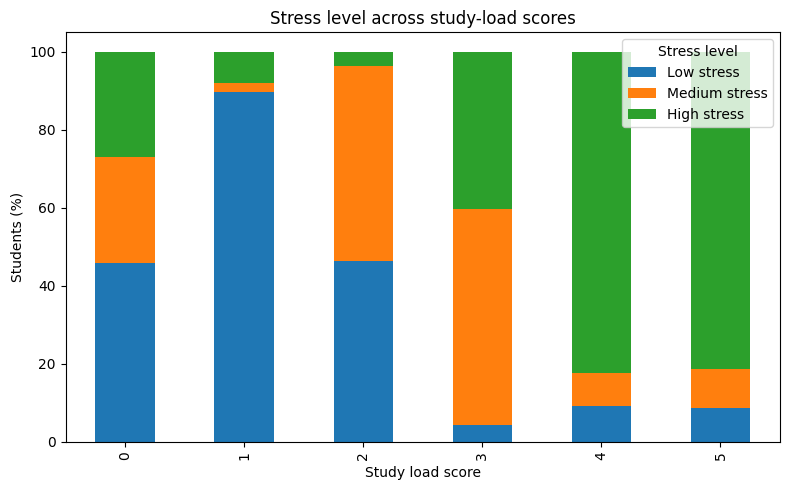

In [13]:
study_ct = pd.crosstab(
    df["study_load"],
    df["stress_level"],
    normalize="index"
) * 100

study_ct = study_ct.rename(columns={
    0: "Low stress",
    1: "Medium stress",
    2: "High stress"
})

ax = study_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_xlabel("Study load score")
ax.set_ylabel("Students (%)")
ax.set_title("Stress level across study-load scores")
ax.legend(title="Stress level")

plt.tight_layout()
plt.savefig(figure_dir / "stress_by_study_load.png", dpi=300, bbox_inches="tight")
plt.show()


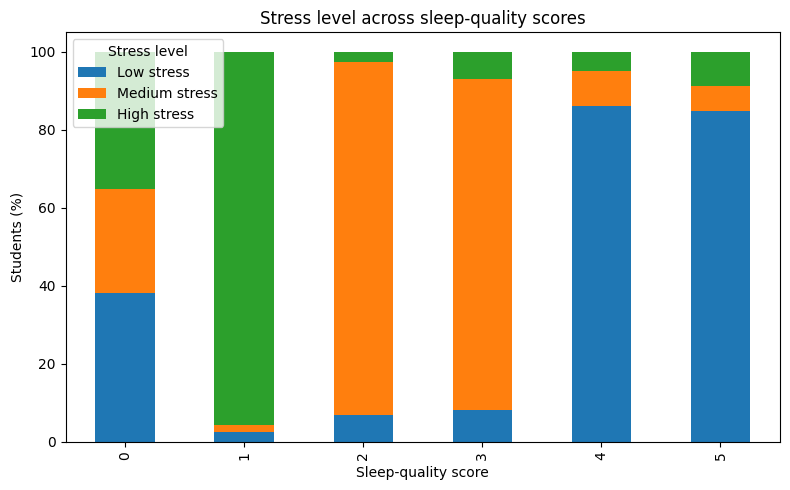

In [14]:
sleep_ct = pd.crosstab(
    df["sleep_quality"],
    df["stress_level"],
    normalize="index"
) * 100

sleep_ct = sleep_ct.rename(columns={
    0: "Low stress",
    1: "Medium stress",
    2: "High stress"
})

ax = sleep_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_xlabel("Sleep-quality score")
ax.set_ylabel("Students (%)")
ax.set_title("Stress level across sleep-quality scores")
ax.legend(title="Stress level")

plt.tight_layout()
plt.savefig(figure_dir / "stress_by_sleep_quality.png", dpi=300, bbox_inches="tight")
plt.show()


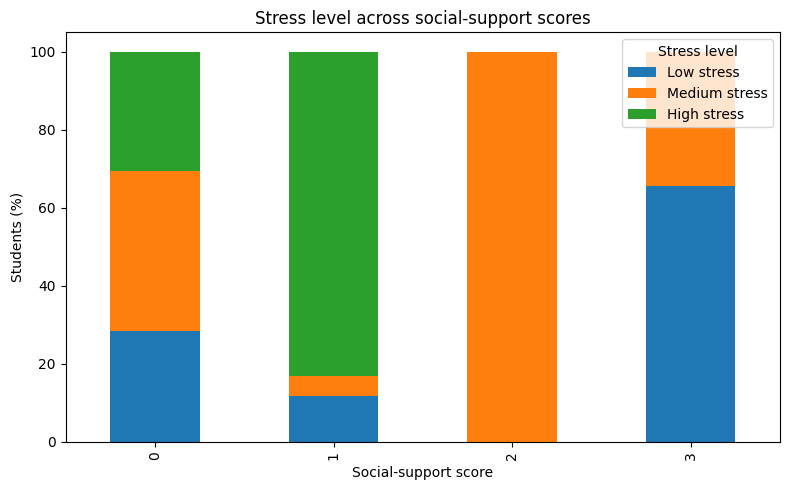

In [15]:
social_ct = pd.crosstab(
    df["social_support"],
    df["stress_level"],
    normalize="index"
) * 100

social_ct = social_ct.rename(columns={
    0: "Low stress",
    1: "Medium stress",
    2: "High stress"
})

ax = social_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_xlabel("Social-support score")
ax.set_ylabel("Students (%)")
ax.set_title("Stress level across social-support scores")
ax.legend(title="Stress level")

plt.tight_layout()
plt.savefig(figure_dir / "stress_by_social_support.png", dpi=300, bbox_inches="tight")
plt.show()


## What the data look like

The three stress groups are fairly balanced overall: about one third of the sample is in each
stress category.

The predictor patterns are strong, but they are not perfectly monotonic. For example:

- At study-load score 2, only 3.6% of students are in the high-stress group, while at scores 4
  and 5 the percentages are 82.4% and 81.2%.
- At sleep-quality score 1, 95.7% are in the high-stress group, while at score 2 most students
  are in the medium-stress group.
- For social-support score 2, all observations in the sample fall in the medium-stress category.

These concentrated patterns suggest a strong relationship between the predictors and stress, but
they also show that the relationship is not simply linear at every score level. This is one reason
to interpret the regression results together with the assumption checks and sensitivity analysis.


## Statistical methods

I used ordinal logistic regression as the main model because `stress_level` has three ordered categories.

I also used:

- Chi-square tests with Cramer's V to look at unadjusted associations.
- Spearman correlation to describe monotonic relationships between the ordered scores.
- VIF to check for multicollinearity between the predictors.
- Two binary logistic models to see whether the proportional-odds assumption looked reasonable.
- Multinomial logistic regression as a sensitivity analysis when that assumption looked questionable.

I did not use ordinary linear regression because the outcome is ordinal rather than continuous.


In [16]:
from scipy.stats import chi2_contingency
import numpy as np

def chi_square_cramers_v(data, x, y):
    table = pd.crosstab(data[x], data[y])

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    r, k = table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(r - 1, k - 1))
    )

    print(f"Variable: {x}")
    print(f"Chi-square = {chi2:.3f}")
    print(f"df = {dof}")
    print(f"p-value = {p:.6f}")
    print(f"Cramer's V = {cramers_v:.3f}")
    print("-" * 40)

for variable in ["study_load", "sleep_quality", "social_support"]:
    chi_square_cramers_v(
        df,
        variable,
        "stress_level"
    )


Variable: study_load
Chi-square = 797.201
df = 10
p-value = 0.000000
Cramer's V = 0.602
----------------------------------------
Variable: sleep_quality
Chi-square = 1520.270
df = 10
p-value = 0.000000
Cramer's V = 0.831
----------------------------------------
Variable: social_support
Chi-square = 1040.588
df = 6
p-value = 0.000000
Cramer's V = 0.688
----------------------------------------


### Chi-square results

The chi-square tests showed statistically significant associations between each explanatory variable and stress level. I also calculated Cramer's V so the result was not based only on p-values.


In [17]:
for variable in ["study_load", "sleep_quality", "social_support"]:

    table = pd.crosstab(df[variable], df["stress_level"])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\nVariable: {variable}")
    print("Minimum expected frequency:", expected.min())
    print("Number of expected cells < 5:", (expected < 5).sum())



Variable: study_load
Minimum expected frequency: 12.041818181818181
Number of expected cells < 5: 0

Variable: sleep_quality
Minimum expected frequency: 11.065454545454546
Number of expected cells < 5: 0

Variable: social_support
Minimum expected frequency: 28.64
Number of expected cells < 5: 0


### Chi-square assumption check

The minimum expected counts were:

- Study load: 12.04
- Sleep quality: 11.07
- Social support: 28.64

All were above 5, so the expected-frequency condition for the chi-square tests was satisfied.


In [18]:
from scipy.stats import spearmanr

for variable in ["study_load", "sleep_quality", "social_support"]:

    rho, p = spearmanr(
        df[variable],
        df["stress_level"]
    )

    print(f"Variable: {variable}")
    print(f"Spearman rho = {rho:.3f}")
    print(f"p-value = {p:.6g}")
    print("-" * 40)


Variable: study_load
Spearman rho = 0.666
p-value = 9.26862e-142
----------------------------------------
Variable: sleep_quality
Spearman rho = -0.761
p-value = 1.57674e-208
----------------------------------------
Variable: social_support
Spearman rho = -0.644
p-value = 1.04843e-129
----------------------------------------


### Spearman correlations

Spearman correlation was used as an additional unadjusted analysis because the variables are ordered scores. It gives both the direction and the strength of the monotonic relationship.


In [19]:
predictors = [
    "study_load",
    "sleep_quality",
    "social_support"
]

predictor_corr = df[predictors].corr(method="spearman")

predictor_corr


,study_load,sleep_quality,social_support
study_load,1.000000,-0.603662,-0.508771
sleep_quality,-0.603662,1.000000,0.586895
social_support,-0.508771,0.586895,1.000000


In [20]:
print(
    df[
        ["study_load", "sleep_quality", "social_support"]
    ].corr(method="spearman").round(3)
)


                study_load  sleep_quality  social_support
study_load           1.000         -0.604          -0.509
sleep_quality       -0.604          1.000           0.587
social_support      -0.509          0.587           1.000


In [21]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[
    ["study_load", "sleep_quality", "social_support"]
].copy()

# Add intercept
X = sm.add_constant(X)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif_table


,Variable,VIF
0,const,20.086510
1,study_load,1.526453
2,sleep_quality,1.710528
3,social_support,1.533228


### Multicollinearity

The VIF values were:

- Study load: 1.53
- Sleep quality: 1.71
- Social support: 1.53

These values are low, so there is no sign of serious multicollinearity between the three predictors.


## Checks for the ordinal logistic model

For the ordinal logistic model, I considered the following points:

1. The stress outcome has a meaningful order: low, medium, high.
2. Each row is treated as an independent observation.
3. The predictors should not be strongly collinear.
4. Treating the predictors as numeric scores assumes a similar effect for each one-unit increase.
5. The proportional-odds assumption should be reasonably consistent across stress thresholds.

The two binary logistic models below are used as a practical check of the last point.


In [22]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

X = df[
    ["study_load", "sleep_quality", "social_support"]
].copy()

y = df["stress_level"]

ordinal_model = OrderedModel(
    y,
    X,
    distr="logit"
)

ordinal_result = ordinal_model.fit(
    method="bfgs",
    disp=False
)

print(ordinal_result.summary())


                             OrderedModel Results                             
Dep. Variable:           stress_level   Log-Likelihood:                -616.90
Model:                   OrderedModel   AIC:                             1244.
Method:            Maximum Likelihood   BIC:                             1269.
Date:                Sun, 13 Sep 2026                                         
Time:                        11:29:14                                         
No. Observations:                1100                                         
Df Residuals:                    1095                                         
Df Model:                           3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
study_load         0.7685      0.078      9.820      0.000       0.615       0.922
sleep_quality     -1.1671      0.072    

In [23]:
import numpy as np
import pandas as pd

predictor_names = [
    "study_load",
    "sleep_quality",
    "social_support"
]

coef = ordinal_result.params[predictor_names]

conf = ordinal_result.conf_int().loc[predictor_names]

or_table = pd.DataFrame({
    "Coefficient": coef,
    "Odds_Ratio": np.exp(coef),
    "CI_2.5%": np.exp(conf[0]),
    "CI_97.5%": np.exp(conf[1]),
    "p_value": ordinal_result.pvalues[predictor_names]
})

or_table.round(4)


,Coefficient,Odds_Ratio,CI_2.5%,CI_97.5%,p_value
study_load,0.7685,2.1566,1.8499,2.5141,0.0
sleep_quality,-1.1671,0.3113,0.2703,0.3584,0.0
social_support,-0.8068,0.4463,0.3772,0.5280,0.0


### Ordinal logistic regression

After adjusting for the other two predictors:

- Study load: OR = 2.16, 95% CI 1.85 to 2.51, p < 0.001
- Sleep quality: OR = 0.31, 95% CI 0.27 to 0.36, p < 0.001
- Social support: OR = 0.45, 95% CI 0.38 to 0.53, p < 0.001

A one-unit increase in study-load score was associated with about 2.16 times the odds of being in
a higher stress category.

Higher sleep-quality and social-support scores were associated with lower odds of being in a
higher stress category. The confidence intervals for all three predictors exclude 1.

These results describe adjusted associations. They do not show that changing any of these factors
would necessarily cause stress to change.


In [24]:
main_results = or_table.copy()
main_results.index = [
    "Study load",
    "Sleep quality",
    "Social support"
]

main_results = main_results[
    ["Odds_Ratio", "CI_2.5%", "CI_97.5%", "p_value"]
].rename(columns={
    "Odds_Ratio": "OR",
    "CI_2.5%": "CI lower",
    "CI_97.5%": "CI upper",
    "p_value": "p-value"
})

for col in ["OR", "CI lower", "CI upper"]:
    main_results[col] = main_results[col].round(3)

main_results["p-value"] = main_results["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

main_results


,OR,CI lower,CI upper,p-value
Study load,2.157,1.850,2.514,<0.001
Sleep quality,0.311,0.270,0.358,<0.001
Social support,0.446,0.377,0.528,<0.001


In [25]:
print(f"Log-Likelihood: {ordinal_result.llf:.2f}")
print(f"AIC: {ordinal_result.aic:.2f}")
print(f"BIC: {ordinal_result.bic:.2f}")


Log-Likelihood: -616.90
AIC: 1243.80
BIC: 1268.81


AIC and BIC are reported to document model fit and make model comparison possible. They are not
measures of predictive accuracy; lower values are useful only when comparing models fitted to the
same outcome and dataset.


In [26]:
import statsmodels.api as sm
import pandas as pd

X = df[
    ["study_load", "sleep_quality", "social_support"]
].copy()

X = sm.add_constant(X)


In [27]:
# low stress vs medium/high stress
y_threshold1 = (df["stress_level"] > 0).astype(int)

logit_1 = sm.Logit(
    y_threshold1,
    X
).fit(disp=False)

print(logit_1.summary())


                           Logit Regression Results                           
Dep. Variable:           stress_level   No. Observations:                 1100
Model:                          Logit   Df Residuals:                     1096
Method:                           MLE   Df Model:                            3
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.4910
Time:                        11:29:14   Log-Likelihood:                -358.57
converged:                       True   LL-Null:                       -704.47
Covariance Type:            nonrobust   LLR p-value:                1.259e-149
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.2950      0.449      7.345      0.000       2.416       4.174
study_load         0.7232      0.096      7.494      0.000       0.534       0.912
sleep_quality     -1.1513      0.086

In [28]:
# low/medium stress vs high stress
y_threshold2 = (df["stress_level"] > 1).astype(int)

logit_2 = sm.Logit(
    y_threshold2,
    X
).fit(disp=False)

print(logit_2.summary())


                           Logit Regression Results                           
Dep. Variable:           stress_level   No. Observations:                 1100
Model:                          Logit   Df Residuals:                     1096
Method:                           MLE   Df Model:                            3
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.5835
Time:                        11:29:14   Log-Likelihood:                -292.31
converged:                       True   LL-Null:                       -701.77
Covariance Type:            nonrobust   LLR p-value:                3.400e-177
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.6750      0.375      4.463      0.000       0.939       2.411
study_load         0.6379      0.083      7.674      0.000       0.475       0.801
sleep_quality     -0.8755      0.083

In [29]:
po_check = pd.DataFrame({
    "Ordinal_Model": ordinal_result.params[
        ["study_load", "sleep_quality", "social_support"]
    ],
    "Threshold_0_vs_1_2": logit_1.params[
        ["study_load", "sleep_quality", "social_support"]
    ],
    "Threshold_0_1_vs_2": logit_2.params[
        ["study_load", "sleep_quality", "social_support"]
    ]
})

po_check.round(3)


,Ordinal_Model,Threshold_0_vs_1_2,Threshold_0_1_vs_2
study_load,0.769,0.723,0.638
sleep_quality,-1.167,-1.151,-0.875
social_support,-0.807,-0.323,-1.643


### Proportional-odds check

I compared the predictor coefficients at two stress thresholds:

| Predictor | Stress 0 vs 1/2 | Stress 0/1 vs 2 |
|---|---:|---:|
| Study load | 0.723 | 0.638 |
| Sleep quality | -1.151 | -0.875 |
| Social support | -0.323 | -1.643 |

The study-load coefficients are fairly similar across the two thresholds. Sleep quality changes somewhat, but social support changes much more.

Because of that difference, the proportional-odds assumption looks questionable for social support. I therefore also fitted a multinomial logistic regression.


In [30]:
import statsmodels.api as sm

X = df[
    ["study_load", "sleep_quality", "social_support"]
].copy()

X = sm.add_constant(X)

y = df["stress_level"]

mn_model = sm.MNLogit(y, X)

mn_result = mn_model.fit(
    method="newton",
    maxiter=200,
    disp=False
)

print(mn_result.summary())


                          MNLogit Regression Results                          
Dep. Variable:           stress_level   No. Observations:                 1100
Model:                        MNLogit   Df Residuals:                     1092
Method:                           MLE   Df Model:                            6
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.4836
Time:                        11:29:14   Log-Likelihood:                -623.93
converged:                       True   LL-Null:                       -1208.3
Covariance Type:            nonrobust   LLR p-value:                2.770e-249
stress_level=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.4273      0.496      4.896      0.000       1.456       3.399
study_load         0.6350      0.104      6.077      0.000       0.430       0.840
sleep_quality     -1.1041      0.091

In [31]:
import numpy as np

mn_or = np.exp(mn_result.params)

mn_or


,0,1
const,11.328240,80.458074
study_load,1.887010,3.172805
sleep_quality,0.331494,0.176373
social_support,0.977143,0.168779


In [32]:
mn_ci = np.exp(mn_result.conf_int())

mn_ci


lower       upper
stress_level                                      
1            const            4.287110   29.933686
             study_load       1.537535    2.315919
             sleep_quality    0.277117    0.396542
             social_support   0.784812    1.216608
2            const           27.137440  238.545035
             study_load       2.503848    4.020488
             sleep_quality    0.139999    0.222197
             social_support   0.119547    0.238286

### Multinomial logistic regression

I used stress level 0 as the reference category.

This model does not assume that the predictor effect is the same at both stress thresholds, so it is useful here as a sensitivity analysis.


In [33]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

study_grid = pd.DataFrame({
    "study_load": range(0, 6),
    "sleep_quality": [df["sleep_quality"].median()] * 6,
    "social_support": [df["social_support"].median()] * 6
})

study_grid_const = sm.add_constant(
    study_grid,
    has_constant="add"
)

study_pred = mn_result.predict(study_grid_const)

study_pred.columns = [
    "Stress_0",
    "Stress_1",
    "Stress_2"
]

study_results = pd.concat(
    [
        study_grid[["study_load"]].reset_index(drop=True),
        study_pred.reset_index(drop=True)
    ],
    axis=1
)

study_results


,study_load,Stress_0,Stress_1,Stress_2
0,0,0.583336,0.399198,0.017466
1,1,0.419050,0.541140,0.039810
2,2,0.267508,0.651860,0.080632
3,3,0.152565,0.701531,0.145904
4,4,0.078671,0.682620,0.238709
5,5,0.037036,0.606410,0.356554


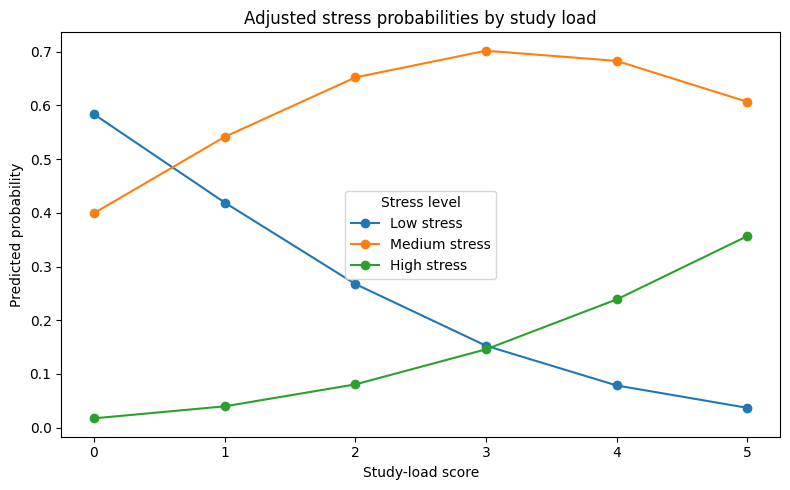

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    study_results["study_load"],
    study_results["Stress_0"],
    marker="o",
    label="Low stress"
)

plt.plot(
    study_results["study_load"],
    study_results["Stress_1"],
    marker="o",
    label="Medium stress"
)

plt.plot(
    study_results["study_load"],
    study_results["Stress_2"],
    marker="o",
    label="High stress"
)

plt.xlabel("Study-load score")
plt.ylabel("Predicted probability")
plt.title("Adjusted stress probabilities by study load")
plt.legend(title="Stress level")
plt.tight_layout()
plt.savefig(figure_dir / "predicted_stress_by_study_load.png", dpi=300, bbox_inches="tight")
plt.show()


In [35]:
sleep_grid = pd.DataFrame({
    "study_load": [df["study_load"].median()] * 6,
    "sleep_quality": range(0, 6),
    "social_support": [df["social_support"].median()] * 6
})

sleep_grid_const = sm.add_constant(
    sleep_grid,
    has_constant="add"
)

sleep_pred = mn_result.predict(sleep_grid_const)

sleep_pred.columns = [
    "Stress_0",
    "Stress_1",
    "Stress_2"
]

sleep_results = pd.concat(
    [
        sleep_grid[["sleep_quality"]].reset_index(drop=True),
        sleep_pred.reset_index(drop=True)
    ],
    axis=1
)

sleep_results


,sleep_quality,Stress_0,Stress_1,Stress_2
0,0,0.015978,0.615379,0.368644
1,1,0.056064,0.715793,0.228143
2,2,0.168066,0.711310,0.120624
3,3,0.395323,0.554635,0.050042
4,4,0.672309,0.312681,0.015010
5,5,0.863475,0.133124,0.003400


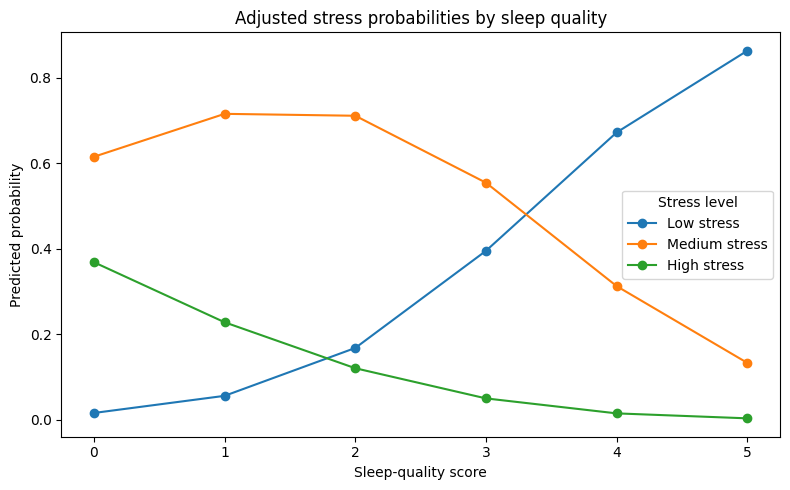

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    sleep_results["sleep_quality"],
    sleep_results["Stress_0"],
    marker="o",
    label="Low stress"
)

plt.plot(
    sleep_results["sleep_quality"],
    sleep_results["Stress_1"],
    marker="o",
    label="Medium stress"
)

plt.plot(
    sleep_results["sleep_quality"],
    sleep_results["Stress_2"],
    marker="o",
    label="High stress"
)

plt.xlabel("Sleep-quality score")
plt.ylabel("Predicted probability")
plt.title("Adjusted stress probabilities by sleep quality")
plt.legend(title="Stress level")
plt.tight_layout()
plt.savefig(figure_dir / "predicted_stress_by_sleep_quality.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
social_grid = pd.DataFrame({
    "study_load": [df["study_load"].median()] * 4,
    "sleep_quality": [df["sleep_quality"].median()] * 4,
    "social_support": range(0, 4)
})

social_grid_const = sm.add_constant(
    social_grid,
    has_constant="add"
)

social_pred = mn_result.predict(social_grid_const)

social_pred.columns = [
    "Stress_0",
    "Stress_1",
    "Stress_2"
]

social_results = pd.concat(
    [
        social_grid[["social_support"]].reset_index(drop=True),
        social_pred.reset_index(drop=True)
    ],
    axis=1
)

social_results


,social_support,Stress_0,Stress_1,Stress_2
0,0,0.070755,0.180575,0.748670
1,1,0.189406,0.472338,0.338256
2,2,0.267508,0.651860,0.080632
3,3,0.291378,0.693798,0.014823


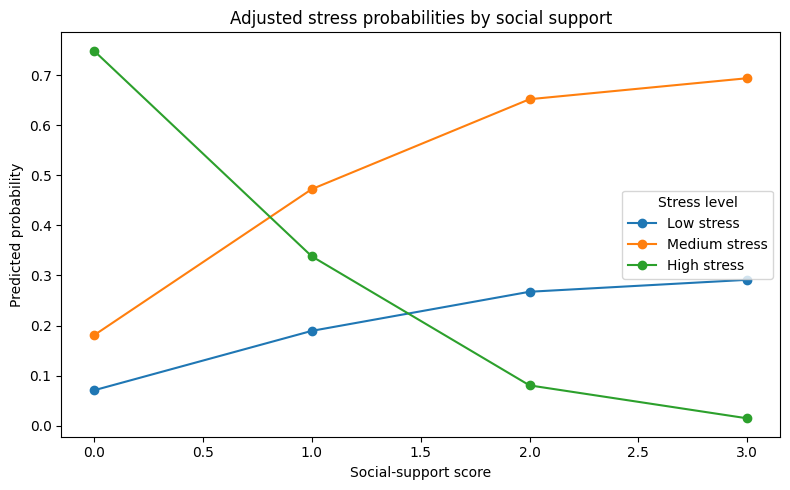

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    social_results["social_support"],
    social_results["Stress_0"],
    marker="o",
    label="Low stress"
)

plt.plot(
    social_results["social_support"],
    social_results["Stress_1"],
    marker="o",
    label="Medium stress"
)

plt.plot(
    social_results["social_support"],
    social_results["Stress_2"],
    marker="o",
    label="High stress"
)

plt.xlabel("Social-support score")
plt.ylabel("Predicted probability")
plt.title("Adjusted stress probabilities by social support")
plt.legend(title="Stress level")
plt.tight_layout()
plt.savefig(figure_dir / "predicted_stress_by_social_support.png", dpi=300, bbox_inches="tight")
plt.show()


### Reading the predicted-probability plots

The adjusted probability plots make the regression results easier to interpret. As study-load
scores increase, the predicted probability of high stress rises. Higher sleep-quality scores show
the opposite pattern. Social support also changes the predicted stress probabilities, but its
pattern is less uniform across categories, which agrees with the proportional-odds check.

These plots hold the other two predictors at their median values, so they describe adjusted model
predictions rather than raw percentages.


## Sensitivity analysis

The multinomial model gave:

### Stress level 1 compared with 0
- Study load: OR = 1.89, 95% CI 1.54 to 2.32, p < 0.001
- Sleep quality: OR = 0.33, 95% CI 0.28 to 0.40, p < 0.001
- Social support: OR = 0.98, 95% CI 0.78 to 1.22, p = 0.836

### Stress level 2 compared with 0
- Study load: OR = 3.17, 95% CI 2.50 to 4.02, p < 0.001
- Sleep quality: OR = 0.18, 95% CI 0.14 to 0.22, p < 0.001
- Social support: OR = 0.17, 95% CI 0.12 to 0.24, p < 0.001

Study load and sleep quality show the same general direction in both models.

Social support is different. It does not clearly separate medium stress from low stress after adjustment, but it is strongly related to high stress compared with low stress. This is why I interpret the social-support result more carefully.


## Limitations

This analysis has several limitations.

First, the dataset is observational, so the results cannot be interpreted as causal effects.

Second, some variables are coded as integer scores, but the full wording and scale anchors are not available in the notebook. This makes one-unit changes harder to interpret in a substantive way.

Third, there is limited information about how the sample was collected, so the results should not automatically be generalized to all students.

The model includes study load, sleep quality, and social support, but other psychological, academic, and environmental factors may also be related to stress.

Some of the relationships in the dataset are also very strong. This is worth keeping in mind when thinking about how the data were generated and how well the findings would generalize to another sample.

Finally, the proportional-odds assumption was not equally convincing for all predictors, especially social support. For that reason, I used the multinomial model as a sensitivity analysis.


## Conclusion

Study load, sleep quality, and social support were associated with stress level in this dataset.

Higher study load was associated with higher stress. Better sleep quality was consistently associated with lower stress.

Social support showed a less uniform pattern. It was strongly related to high versus low stress, but it did not clearly distinguish medium from low stress after adjustment in the multinomial model.

Overall, the most consistent findings were for study load and sleep quality. The social-support result should be interpreted more carefully.

Since the study is observational, these results should be described as associations rather than causes.


## Why I chose this model

The main model was ordinal logistic regression because the outcome has three ordered categories.

A multinomial logistic model was also considered. It does not use the ordering of the outcome, so I did not use it as the first model. However, it is useful when the proportional-odds assumption is questionable.

The threshold checks suggested that social support did not have the same relationship at both stress cutoffs. For that reason, I used the multinomial model as a second analysis and compared the results.

The main assumptions I considered were outcome ordering, independent observations, multicollinearity, the numeric-score specification, and proportional odds.


## Before submitting

1. Put `StressLevelDataset.csv` inside the `data/` folder.
2. Restart the kernel and run the notebook from the first cell to the last cell.
3. Check that there are no error messages.
4. Make sure the six final figures are saved in `figures/`.
5. Keep `README.md` and `requirements.txt` in the repository root.
6. Do not change or remove a result just because it is not statistically significant.

A clean final repository should look like this:

```text
academic-stress-research/
├── README.md
├── requirements.txt
├── data/
│   └── StressLevelDataset.csv
├── notebooks/
│   └── finalresreach_FINAL_REVIEWED.ipynb
└── figures/
    ├── stress_by_study_load.png
    ├── stress_by_sleep_quality.png
    ├── stress_by_social_support.png
    ├── predicted_stress_by_study_load.png
    ├── predicted_stress_by_sleep_quality.png
    └── predicted_stress_by_social_support.png
```


In [39]:
# Package versions
import sys
import scipy
import statsmodels
import matplotlib

versions = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "matplotlib": matplotlib.__version__,
}
pd.Series(versions, name="version")


python         3.13.5
pandas          2.2.3
numpy           2.3.5
scipy          1.17.0
statsmodels    0.14.6
matplotlib     3.10.8
Name: version, dtype: object